In [1]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [6]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy

from torch import nn
from umap import UMAP

from run_sim import *
from utils import cosine_similarity, get_r_2, vector_angle
from tqdm import tqdm



In [7]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [8]:
C = Config()

C.G = 0.8
# C.gpu_id=1
# C.seed = 1
C.linear_net = True
C.split_actions = True
# C.allow_backwards = True
C.learning_rate = 0.1
C.L=5
C.print_progress = True
C.length_corridors = [10]*2
C.max_move = 5
C.hidden_size = 21
C.num_epochs *= 10
C.algo_name = 'SGD'
C.fixed_output = False
C.loss_fn = nn.MSELoss()
C.bias = False
# C.input_size = 100
# C.fixed_output = False
# C.split_actions = False
# C.allow_backwards = True

# C.min_move = 2
# C.one_hot_actions = True
# C.one_hot_inputs = False

In [9]:
data_dict = run_sim_wrapper(C)

X = data_dict['X']
y = data_dict['y']
hidden_states = data_dict['hidden_states']
action_taken = data_dict['action_taken']
loc_y = data_dict['loc_y']
corridor = data_dict['corridor']

print(calc_h_var(C.G, X.shape[1], C.hidden_size, C.L, X.var().cpu().numpy()))
hidden = hidden_states[-1].detach().cpu().numpy()
X_dist = torch.cdist(X, X).cpu().numpy()
y_dist = torch.cdist(y, y).cpu().numpy()
hidden_dist = torch.cdist(hidden_states[-1].detach(), hidden_states[-1].detach()).cpu().numpy()
stay_inds = np.where(action_taken == 0)[0]
loc_y_corridor = loc_y + (corridor * max(loc_y + 1))

X_np = X.cpu().numpy() # Convert to numpy array if X is a torch tensor
y_np = y.cpu().numpy() # Convert to numpy array if y is a torch tensor
h_np = hidden # Convert to numpy array if hidden is a torch tensor

Number of samples: 160
Input dimension: 42
Output dimension: 20
Number of actions: 22

Sig_2 of last hidden: 0.006053181365132332


100%|██████████| 100000/100000 [02:13<00:00, 750.61it/s]

0.006493736000000004


So far:

1. Ordering and alignment happen in a wide range of linear network hyper-parameters.
2. I haven't found the same with MSE loss, but likely and can be produced because it was seen in non-linear network.
3. Solutions are generally low-dim, but not necessarily. Performance still depends on many PCs.
4. One amazing detail is that only PC1 seems to be ordered and not the others, which raises the question why? Performance doesn't depend on it exclusively, so why would this very humanly appealing but network-wise senseless structure appear?
5. So far I haven't found linear relationship between action representations as hinted in Stefano's work, but there does seem to be some tuning of neurons to actions that is sometimes linear.
6. Another striking result is that the product of weights does not 100% match the input-output correlation matrix, but rather it has the added correlation that aligns corridors. This is in contrast to results from Saxe 2014, though of course not comparable because of the different loss function. That being said, it is strange to see that it is almost the same but with a very structured added component.
7. Can also see results in single hidden layer but they are less linear
8. How can hiddens have low PR and weights have high PR?
9. Can also get alingment in split_action
10. For the simplest setting a_2 - a_0 / a_1 - a_0 = 2

Origin of results:
It seems that when max_move increases, the networks tends to become not only low-dimensional but also that representations lay on a linear manifold (in this case a line - what happens in 2d env?). It is possible that the solution is always low-dimensional but the manifolds are non-linear, though unlikely, because I only used linear dimensionality measures.
This seems paradoxical - the input dimension increases while the representation dimension decreases. Stefano et al suggests implicit regularization from SGD but here there is no batch noise, so this simplicity bias does not come from noise.

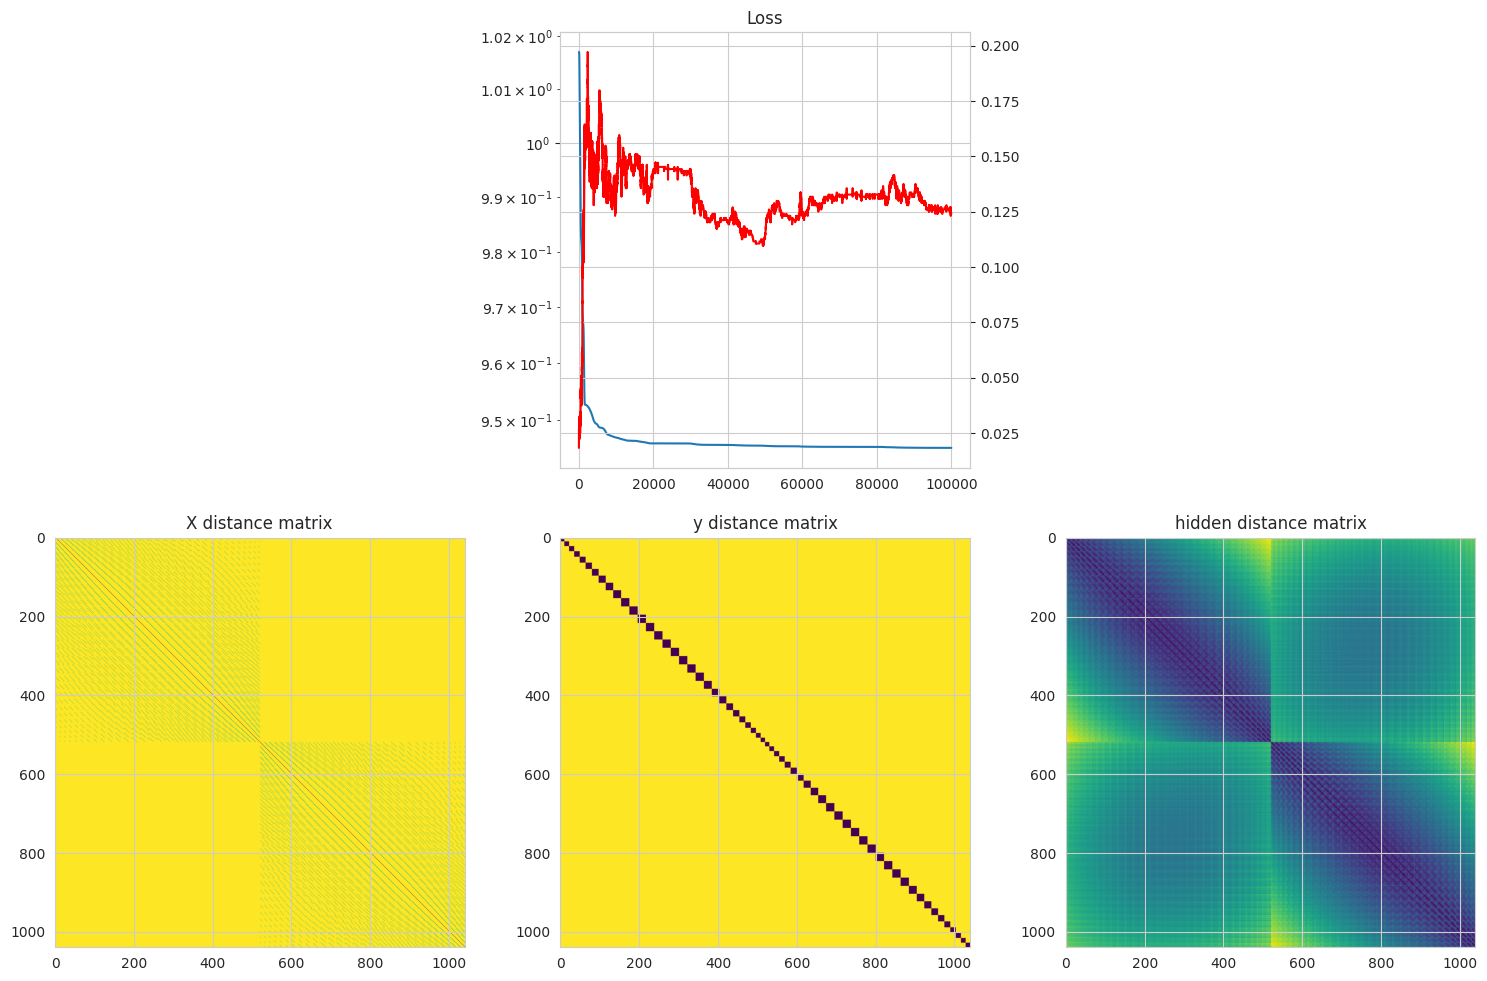

In [ ]:
indices = np.lexsort((loc_y, corridor))
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0,0].set_axis_off(); axs[0,2].set_axis_off()
axs[0,1].plot(loss_l)
axs[0,1].set_yscale('log')
axs[0,1].twinx().plot(accuracy_l, 'r')
axs[0,1].set_title("Loss")
for var, var_name, ax in zip([X_dist, y_dist, hidden_dist], ['X', 'y', 'hidden'], axs[1]):
    ax.imshow(var[indices][:, indices], cmap='viridis')
    ax.set_title(f'{var_name} distance matrix')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, '$V_{11}$')

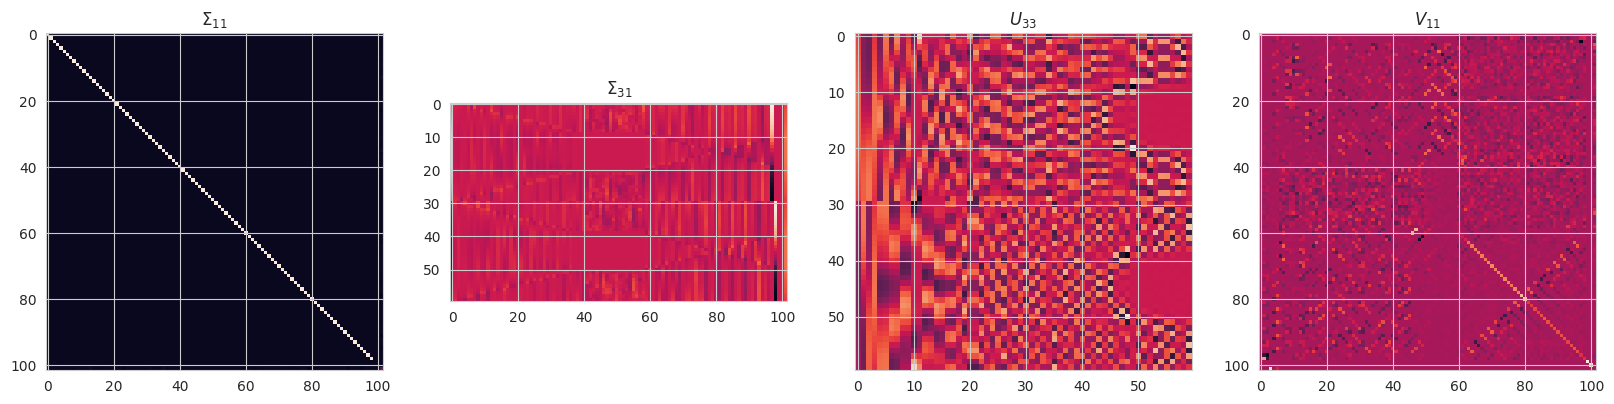

In [ ]:
X_np = X.cpu().numpy()
pca = PCA(whiten=True)
X_np = pca.fit_transform(X_np)

sigma11 = np.sum([xi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
sigma31 = np.sum([yi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
U33,S, V11 = np.linalg.svd(sigma31)
V11 = V11.T

fig, axs = plt.subplots(1, 4, figsize=(20, 10))
axs[0].imshow(sigma11); axs[0].set_title('$\Sigma_{11}$')
axs[1].imshow(sigma31); axs[1].set_title('$\Sigma_{31}$')
axs[2].imshow(U33); axs[2].set_title('$U_{33}$')
axs[3].imshow(V11); axs[3].set_title('$V_{11}$')

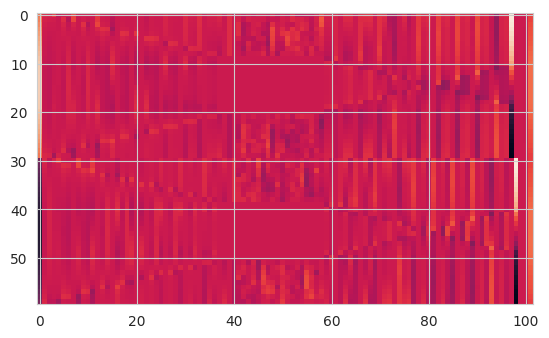

In [ ]:
plt.imshow(U33@np.concatenate([np.diag(S), np.zeros([U33.shape[0], V11.shape[0]-U33.shape[0]])],1)@V11.T)

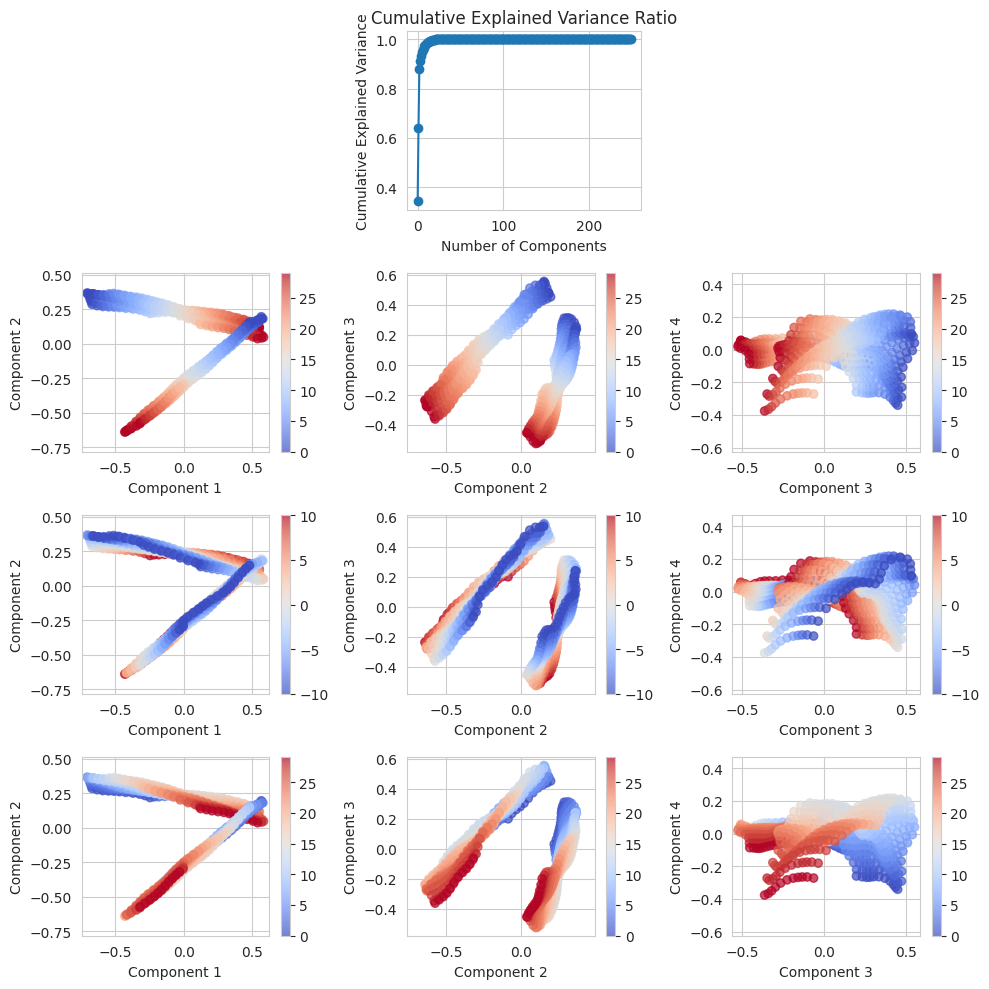

In [ ]:
pca = PCA().fit(h_np)
X_reduced = pca.transform(h_np)
fig = plt.figure(figsize=(10, 10))

# Add cumulative explained variance ratio in the first row
ax1 = fig.add_subplot(4, 3, 2)
ax1.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Explained Variance')
ax1.set_title('Cumulative Explained Variance Ratio')

# Add scatter plots in the second row
for i in range(3):
    for j, c in enumerate([loc_y, action_taken, loc_X]):
        ax = fig.add_subplot(4, 3, i + 4 + j*3)
        # c = loc_y
        # c = action_taken[inds]
        s = ax.scatter(X_reduced[:, i], X_reduced[:, i+1], c=c, cmap='coolwarm', alpha=0.7)
        ax.set_xlabel(f'Component {i+1}')
        ax.set_ylabel(f'Component {i+2}'),
        ax.axis('equal')
        fig.colorbar(s, ax=ax)

plt.tight_layout()
plt.show()

In [ ]:

output_weights = final_weights['output_layer.weight'].cpu().detach().numpy()
n_corridors = len(C.length_corridors)
pca = PCA(); pca_corridors = [PCA() for _ in range(n_corridors)];
[p.fit(hidden[corridor == i]) for i, p in enumerate(pca_corridors)]
pca.fit(hidden)
h_transformed = pca.transform(h_np)
h_transformed_l = [p.transform(h_np[corridor == i]) for i, p in enumerate(pca_corridors)]
pca_accuracy_l = []
pca_explained_var_l = []
pca_loss_l = []
order_l = []
n_pcs = np.arange(1, min(min([min(h_transformed_l[i].shape) for i in range(n_corridors)]), 100))
for n in n_pcs:
    # h_reconstructed = pca.inverse_transform(h_transformed)
    h_reconstructed = h_transformed[:,:n] @ pca.components_[:n] + pca.mean_
    y_hat_pca = (h_reconstructed @ output_weights.T)
    # print(f'accuracy of first {n} PCs: {(y_hat_first_pc == y.argmax(1).cpu().detach().numpy()).mean()}')
    pca_accuracy_l.append((y_hat_pca.argmax(1) == y_np.argmax(1)).mean())
    pca_explained_var_l.append(pca.explained_variance_ratio_[:n].sum())
    pca_loss_l.append(nn.CrossEntropyLoss()(torch.tensor(y_hat_pca), y.cpu()).item())
    order = [get_r_2(h[:, [n-1]], loc_y[corridor == i]) for i, h in enumerate(h_transformed_l)]
    order_l.append(np.mean(order))

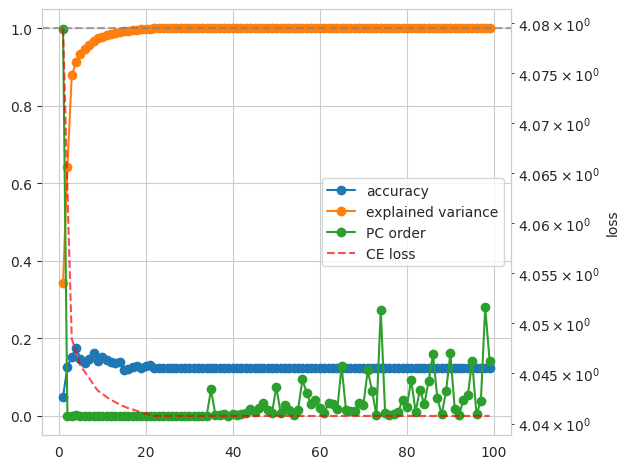

In [ ]:
fig, ax1 = plt.subplots()
plt.plot(n_pcs, pca_accuracy_l, label='accuracy', marker='o')
plt.plot(n_pcs, pca_explained_var_l, label='explained variance', marker='o')
plt.plot(n_pcs, order_l, label='PC order', marker='o')
plt.axhline(1, color='gray', ls='--', alpha=0.7)
ax2 = ax1.twinx()
ax2.set_ylabel('loss')
ax2.plot(n_pcs, pca_loss_l, 'r', label='CE loss', ls='--', alpha=0.7)
ax2.set_yscale('log')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right')
plt.xlabel('number of PCs')
# plt.xscale('log')
plt.tight_layout()
plt.show()

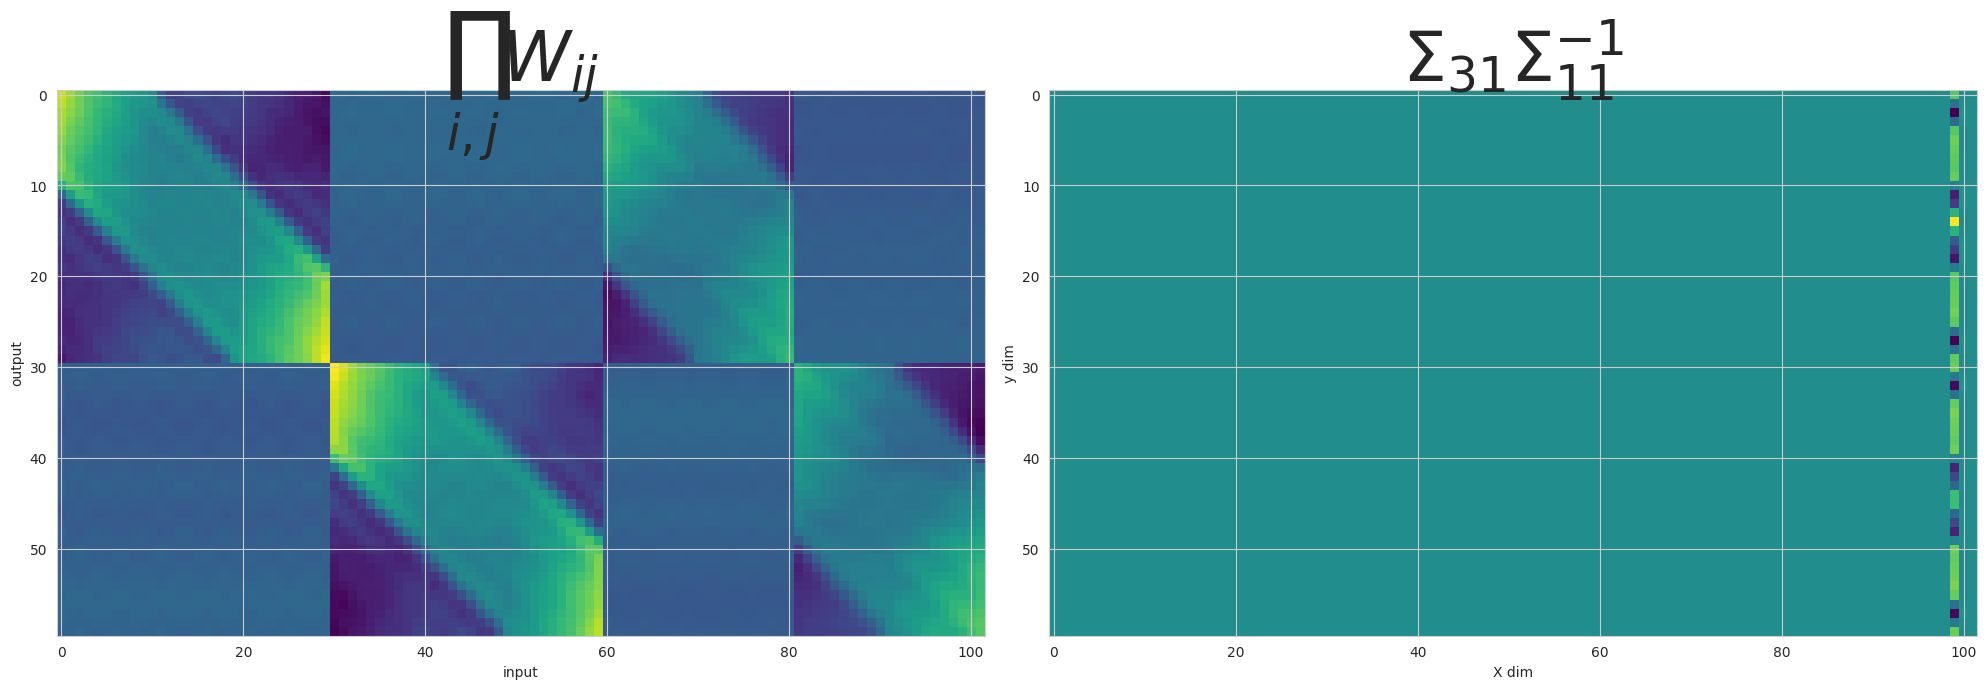

In [ ]:
W_l = [W.cpu().numpy() for W in final_weights.values()]
result = W_l[0].T
for W in W_l[1:]:
    result = np.matmul(result, W.T)

# Sigma = np.corrcoef(X_np.T, y_np.T)
# Sigma31 = Sigma[X_np.shape[1]:, :X_np.shape[1]]
# Sigma11 = Sigma[:X_np.shape[1], :X_np.shape[1]]
Sigma31 = np.sum([yi[:,None]@xi[None,:] for xi, yi in zip(X_np, y_np)], 0)
Sigma11 = np.sum([xi[:,None]@xi[None,:] for xi in X_np], 0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 20))
# ax1.imshow(W32@W21)
ax1.imshow(result.T, cmap='viridis')
ax1.set_ylabel('output')
ax1.set_xlabel('input')
ax1.set_title(r'$\prod_{i,j} W_{ij}$', fontsize=50)
im = ax2.imshow(Sigma31@np.linalg.pinv(Sigma11), cmap='viridis')
ax2.set_title('$\Sigma_{31}\Sigma_{11}^{-1}$', fontsize=50)
ax2.set_xlabel('X dim')
ax2.set_ylabel('y dim')
plt.tight_layout()
plt.show()

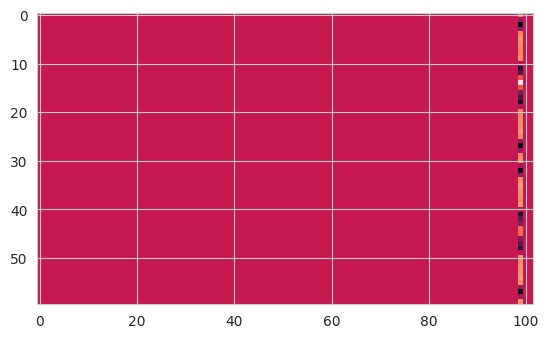

In [ ]:
import numpy as np

def factorize_matrix(M, N=None):
    D1, D2 = M.shape
    # Compute full SVD
    U, S, Vt = np.linalg.svd(M, full_matrices=False)
    rank = np.sum(S > 1e-10)  # numerical rank

    if N is None:
        N = rank  # default N to rank(M)
    elif N < rank:
        raise ValueError(f"N must be >= rank(M)={rank} for exact reconstruction")

    # Take the first N components
    U_N = U[:, :N]
    S_N = np.diag(S[:N])
    Vt_N = Vt[:N, :]

    A = U_N @ np.sqrt(S_N)
    B = np.sqrt(S_N) @ Vt_N
    return A, B

# Example:
M = Sigma31@np.linalg.pinv(Sigma11)
A, B = factorize_matrix(M, N=C.hidden_size)
M_reconstructed = A @ B
plt.imshow(M_reconstructed)


In [ ]:
# # Compute participation ratio for a matrix
# def compute_participation_ratio(matrix):
#     eigenvalues = np.linalg.eigvalsh(matrix @ matrix.T)  # Compute eigenvalues of the covariance matrix
#     eigenvalues = eigenvalues[eigenvalues > 1e-10]  # Filter out near-zero eigenvalues for numerical stability
#     pr = (np.sum(eigenvalues) ** 2) / np.sum(eigenvalues ** 2)
#     return pr
#
# # Compute PR for each weight matrix in final_weights
# participation_ratios = {}
# for name, weight in final_weights.items():
#     weight_np = weight.cpu().detach().numpy()  # Convert to numpy
#     participation_ratios[' '.join(name.split('.')[:-1])] = compute_participation_ratio(weight_np)
#
# # Compute PR for each weight matrix in final_weights
# participation_ratios_h = {}
# for i, h in enumerate([X] + hidden_states + [y]):
#     hid_np = h.cpu().detach().numpy()  # Convert to numpy
#     participation_ratios_h[f'hidden_{i+1}'] = compute_participation_ratio(hid_np)
#
# # Plot the participation ratios
# fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10, 6))
# ax1.plot(participation_ratios.keys(), participation_ratios.values(), color='skyblue')
# ax1.set_ylim(0)
# ax1.set_xticklabels(participation_ratios.keys(), rotation=45, ha='right')
# ax2.plot(participation_ratios_h.keys(), participation_ratios_h.values(), color='orange')
# # ax2.set_xticks(rotation=45, ha='right')
# ax1.set_ylabel('Participation Ratio')
# ax2.set_ylim(0)
# fig.suptitle('Participation Ratio of Weight Matrices and hiddens')
# plt.tight_layout()
# plt.show()

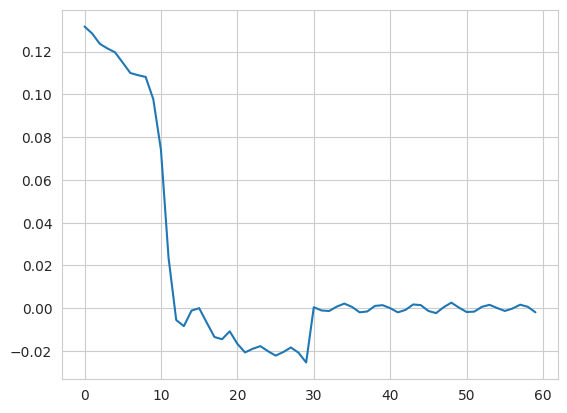

In [ ]:
plt.plot(outputs[0], label='output')
plt.show()

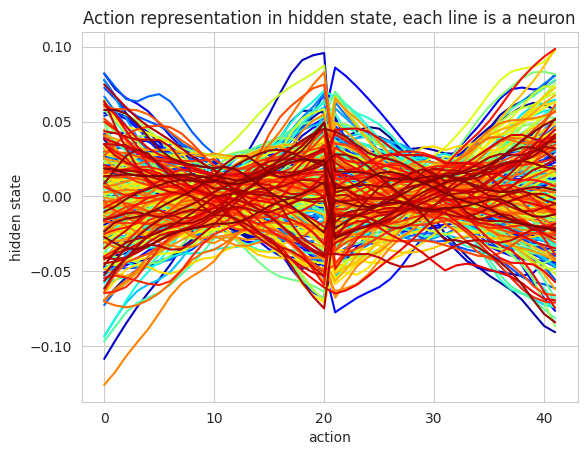

In [ ]:
n_actions = X.shape[1] - sum(C.length_corridors)
a_in_hidden = np.concatenate([np.zeros([n_actions, y.shape[1]]), np.eye(n_actions)],1)
n_states = X.shape[1] - n_actions
s_in_hidden = np.concatenate([np.eye(n_states), np.zeros([n_states, n_actions])],1)
for W in W_l[:-1]:
    a_in_hidden = a_in_hidden @ W.T
    s_in_hidden = s_in_hidden @ W.T

colors = plt.cm.jet(np.linspace(0, 1, a_in_hidden.shape[1]))
for i, color in enumerate(colors):
    plt.plot(np.arange(n_actions), a_in_hidden[:, i], color=color)
plt.xlabel('action')
plt.ylabel('hidden state')
plt.title('Action representation in hidden state, each line is a neuron')
plt.show()


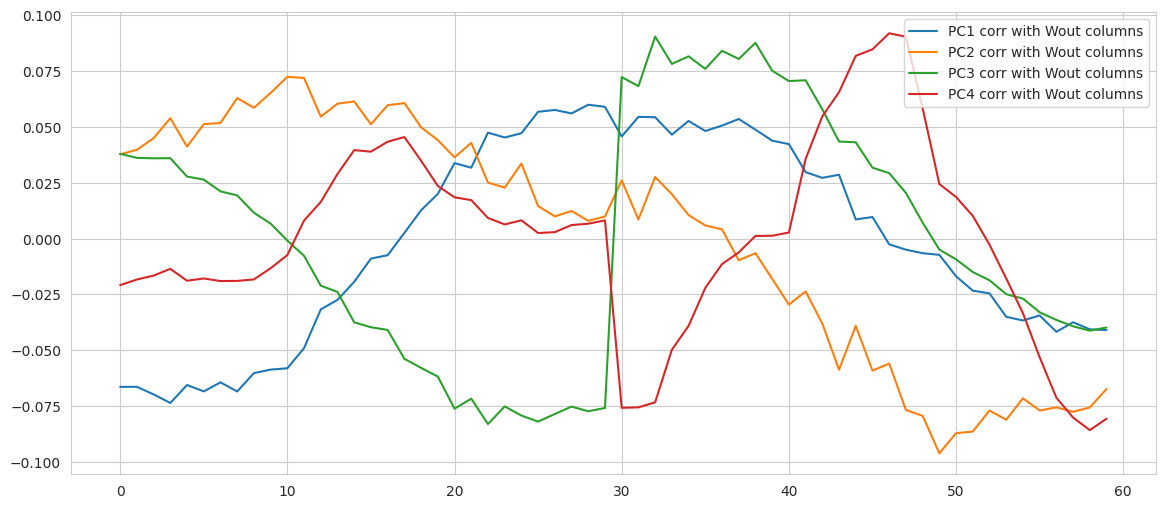

In [ ]:
Wout = final_weights['output_layer.weight'].cpu().detach().numpy().T
pca_comps = pca.components_
plt.figure(figsize=(14, 6))
plt.plot(np.corrcoef(Wout.T, pca_comps[[0]])[-1, :-1], label='PC1 corr with Wout columns')
plt.plot(np.corrcoef(Wout.T, pca_comps[[1]])[-1, :-1], label='PC2 corr with Wout columns')
plt.plot(np.corrcoef(Wout.T, pca_comps[[2]])[-1, :-1], label='PC3 corr with Wout columns')
plt.plot(np.corrcoef(Wout.T, pca_comps[[3]])[-1, :-1], label='PC4 corr with Wout columns')
plt.legend()
plt.show()

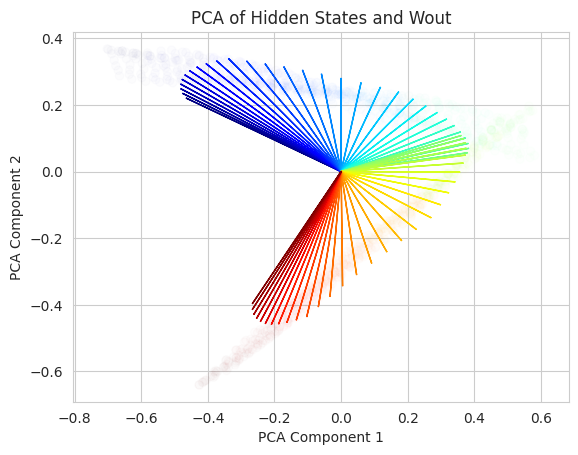

In [ ]:
h_pca = pca.transform(hidden)
Wout_pca = pca.transform(Wout.T)
# scale Wout_pca to be in the same scale as h_pca
Wout_pca = 1*(Wout_pca - Wout_pca.mean(axis=0)) / Wout_pca.std(axis=0) * h_pca.std(axis=0) + h_pca.mean(axis=0)
plt.scatter(h_pca[:, 0], h_pca[:, 1], c=loc_y_corridor, cmap='jet', alpha=0.01)
cmap = plt.cm.jet(np.linspace(0, 1, Wout.shape[1]))
for i in range(Wout.shape[1]):
    plt.arrow(0, 0, Wout_pca[i, 0], Wout_pca[i, 1], color=cmap[i], width=Wout_pca.std()/100)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of Hidden States and Wout')
plt.axis('equal')
plt.show()

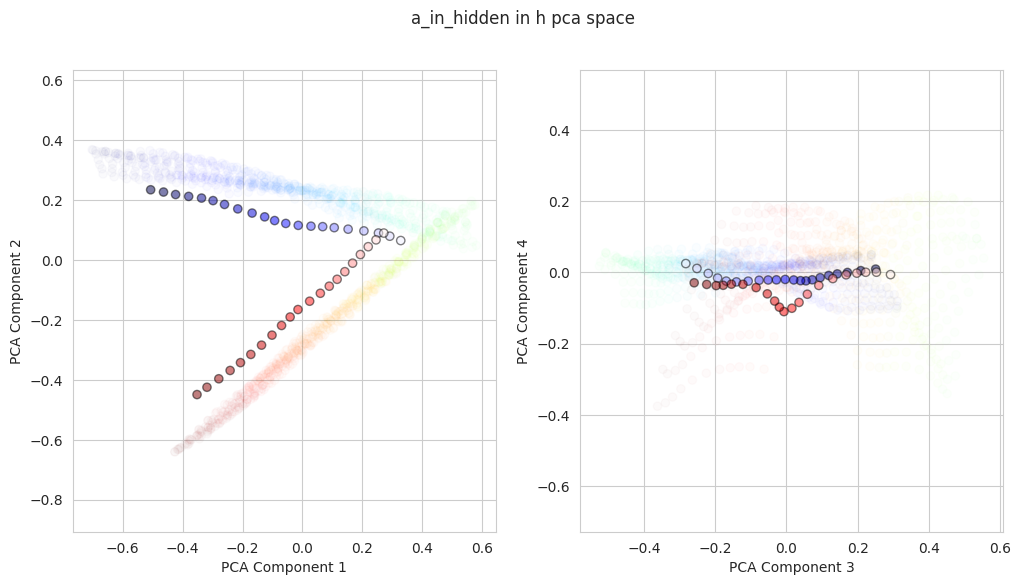

In [ ]:
a_in_hidden_pca = pca.transform(a_in_hidden)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for i in range(2):
    ax = axs[i]
    ax.scatter(h_pca[:, i*2], h_pca[:, i*2+1], c=loc_y_corridor, cmap='jet', alpha=0.02)
    ax.scatter(a_in_hidden_pca[:, i*2], a_in_hidden_pca[:, i*2+1], c=np.arange(n_actions), cmap='seismic', alpha=0.5, label='a_in_hidden PCA', edgecolor='k')
    ax.set_xlabel(f'PCA Component {i*2+1}')
    ax.set_ylabel(f'PCA Component {i*2+2}')
    ax.axis('equal')
fig.suptitle('a_in_hidden in h pca space')
plt.show()

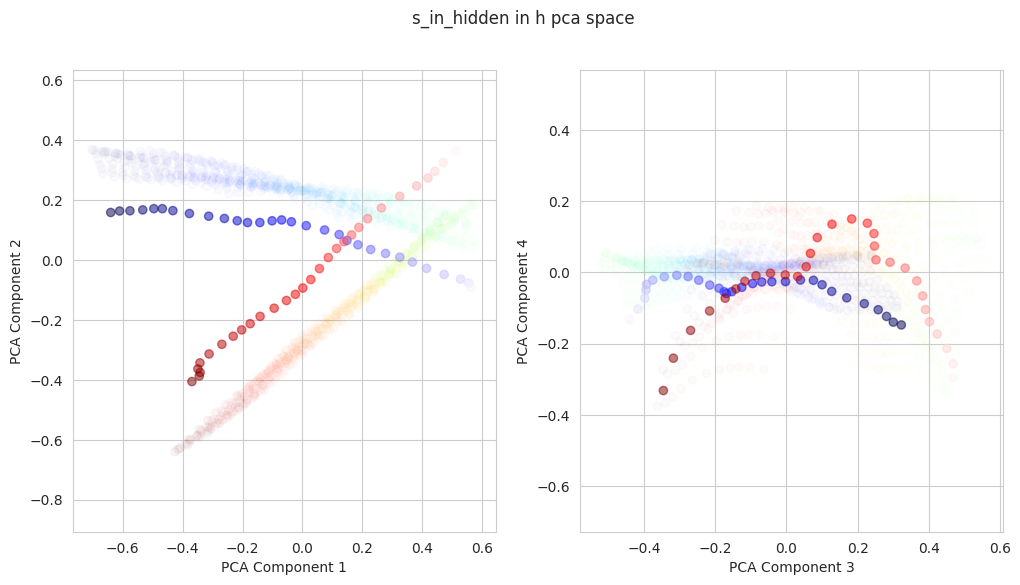

In [ ]:
s_in_hidden_pca = pca.transform(s_in_hidden)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for i in range(2):
    ax = axs[i]
    ax.scatter(h_pca[:, i*2], h_pca[:, i*2+1], c=loc_y_corridor, cmap='jet', alpha=0.02)
    ax.scatter(s_in_hidden_pca[:, i*2], s_in_hidden_pca[:, i*2+1], c=np.arange(n_states), cmap='seismic', alpha=0.5, label='s_in_hidden PCA')
    ax.set_xlabel(f'PCA Component {i*2+1}')
    ax.set_ylabel(f'PCA Component {i*2+2}')
    ax.axis('equal')
fig.suptitle('s_in_hidden in h pca space')
plt.show()

100%|██████████| 100/100 [00:07<00:00, 13.76it/s]

Within cluster distance normalized by between cluster distances: 3.59
Within cluster distance normalized by mean hidden norm: 0.43


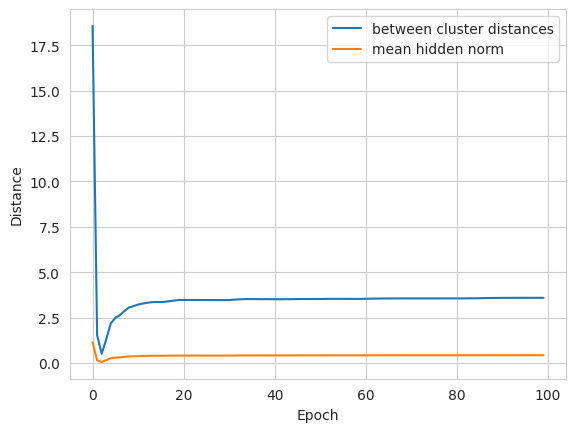

In [ ]:
from utils import get_upper_triangle

d_b = []
d_n = []
for h in tqdm(hidden_l[1::10]):
    h = torch.tensor(h[-1]).to('cuda:2')
    hidden_centers = torch.stack([h[y[:,i]==1].mean(0) for i in range(y.shape[1])])
    hidden_between_cluster_dists = torch.diag(torch.cdist(hidden_centers, hidden_centers),1).mean().item()
    hidden_within_cluster_dists = torch.tensor([get_upper_triangle(torch.cdist(h[y[:,i]==1], h[y[:,i]==1])).mean() for i in range(y.shape[1])]).mean().item()
    hidden_mean_norm = torch.linalg.norm(h, dim=1).mean().item()
    d_n.append(hidden_within_cluster_dists / hidden_mean_norm)
    d_b.append(hidden_within_cluster_dists / hidden_between_cluster_dists)
print(f'Within cluster distance normalized by between cluster distances: {d_b[-1]:.2f}')
print(f'Within cluster distance normalized by mean hidden norm: {d_n[-1]:.2f}')

plt.plot(d_b, label='between cluster distances')
plt.plot(d_n, label='mean hidden norm')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Distance')
plt.show()

In [ ]:
import torch
import torch.nn.functional as F

def compute_hessian(W_l, x, target):
    """
    Compute the Hessian of MSE loss w.r.t. the flattened parameters.

    Args:
        W_l (list of torch.Tensor): List of weight matrices (no bias).
        x (torch.Tensor): Input tensor of shape (batch_size, in_features).
        target (torch.Tensor): Target tensor of shape (batch_size, out_features).

    Returns:
        torch.Tensor: 2D Hessian matrix of shape (num_params, num_params).
    """
    # Make sure weights require gradients
    W_l = [w.clone().detach().requires_grad_(True) for w in W_l]

    # Forward pass through layers
    out = x
    for W in W_l:
        out = out @ W.T  # Linear layer without bias

    # Loss (mean squared error)
    loss = F.mse_loss(out, target)

    # Flatten parameters
    params_vector = torch.cat([w.view(-1) for w in W_l])

    # Compute gradients (first-order)
    grads = torch.autograd.grad(loss, W_l, create_graph=True)
    grads_vector = torch.cat([g.view(-1) for g in grads])

    num_params = params_vector.numel()
    hessian = torch.zeros(num_params, num_params)

    for i in range(num_params):
        grad2rd = torch.autograd.grad(grads_vector[i], W_l, retain_graph=True)
        grad2rd_vector = torch.cat([g.contiguous().view(-1) for g in grad2rd])
        hessian[i] = grad2rd_vector

    return hessian


In [ ]:
num_params = sum([len(W.flatten()) for W in W_l])**2
print(num_params)
if num_params < 1e7:
    weights_for_hess = [W for W in final_weights.values()]
    hessian = compute_hessian(weights_for_hess, X, y)
    L, V = torch.linalg.eig(hessian)
    plt.figure(figsize=(12, 6))
    plt.plot(np.abs(L.numpy()))
    plt.yscale('log')


24780484000000
